# Score Matching in Diffusion Models

In practice, we do not know the data distribution $p_t(x)$ beforehand, so we cannot calculate the exact Score function (Analytical Score). Therefore, we must train a **neural network** to learn and approximate it:
$$ s_\theta(x, t) \approx \nabla_x \log p_t(x) $$

This training process is called **Denoising Score Matching**.

In this Notebook, we will define a simple MLP model using PyTorch to learn the Score function, then use it to solve the Reverse SDE equation and generate new data.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Common parameters
x0 = 5.0      # Original data (target)
beta = 1.0    # SDE diffusion coefficient
T = 3.0       # Total time
N_steps = 1000
dt = T / N_steps
n_particles = 1000

### 1. Defining the Neural Network for the Score Function

In [8]:
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        # A simple Multi-Layer Perceptron (MLP) with 3 hidden layers
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x, t):
        # Concatenate x and t into input tensor (Batch_size, 2)
        _input = torch.cat([x, t], dim=-1)
        return self.net(_input)

model = ScoreNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### 2. Training the Model via Denoising Score Matching

Loss Function for Denoising Score Matching:
$$ L(\theta) = \mathbb{E}_{t, x_0, \epsilon} \left[ \left\| s_\theta(x_t, t) \cdot \sigma(t) + \epsilon \right\|^2 \right] $$
Where $\sigma(t) = \sqrt{1 - e^{-\beta t}}$ is the standard deviation of the noise at step $t$.

Epoch  500 | Loss: 0.0402
Epoch 1000 | Loss: 0.0254
Epoch 1500 | Loss: 0.0156
Epoch 2000 | Loss: 0.0068
Epoch 2500 | Loss: 0.0088


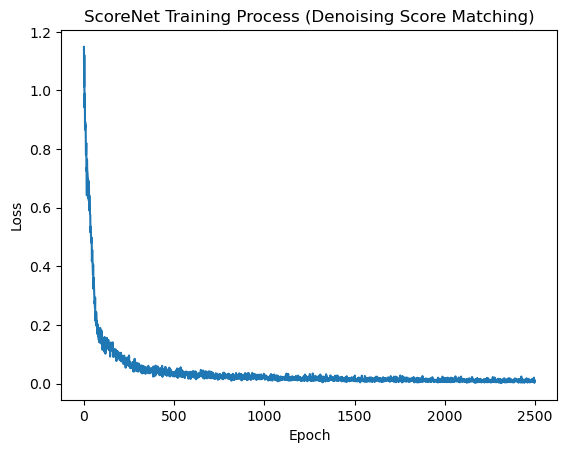

In [9]:
epochs = 2500
batch_size = 1024
x0_tensor = torch.full((batch_size, 1), x0)

loss_history = []

model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 1. Sample random time t in range (0, T]
    t = torch.rand(batch_size, 1) * T + 1e-4
    
    # 2. Add noise: Sample x_t from the analytical formula p(x_t | x_0)
    mean = x0_tensor * torch.exp(-0.5 * beta * t)
    std = torch.sqrt(1.0 - torch.exp(-beta * t))
    epsilon = torch.randn_like(x0_tensor)
    x_t = mean + std * epsilon
    
    # 3. Predict Score using the Neural Network
    score_pred = model(x_t, t)
    
    # 4. Calculate Denoising Score Matching Loss
    # Use lambda(t) = std^2 to balance the loss, normalizing it to predicting -epsilon
    loss = torch.mean((score_pred * std + epsilon) ** 2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if (epoch+1) % 500 == 0:
        print(f"Epoch {epoch+1:4d} | Loss: {loss.item():.4f}")

plt.plot(loss_history)
plt.title("ScoreNet Training Process (Denoising Score Matching)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### 3. Generating Data with the Learned Neural Network (Reverse SDE)

We start with pure noise $x_T \sim \mathcal{N}(0, 1)$ and go backwards in time through the equation:
$$ dx = \left[ -\frac{1}{2}\beta x - \beta s_\theta(x, t) \right] dt + \sqrt{\beta} d\bar{w} $$

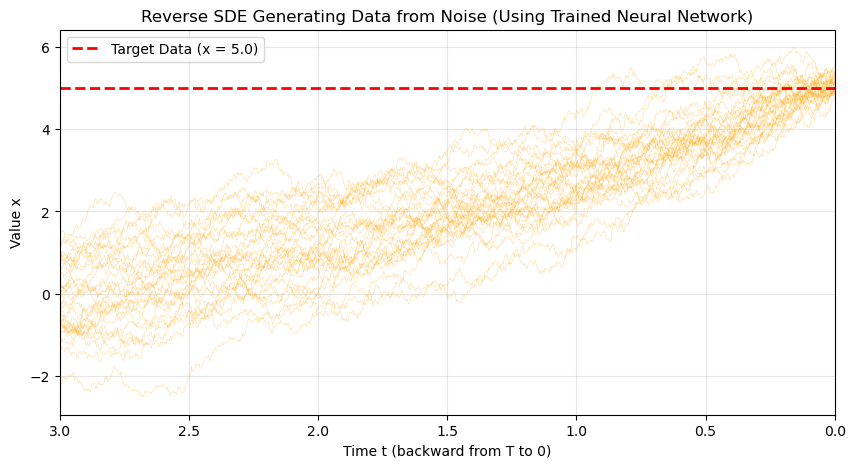

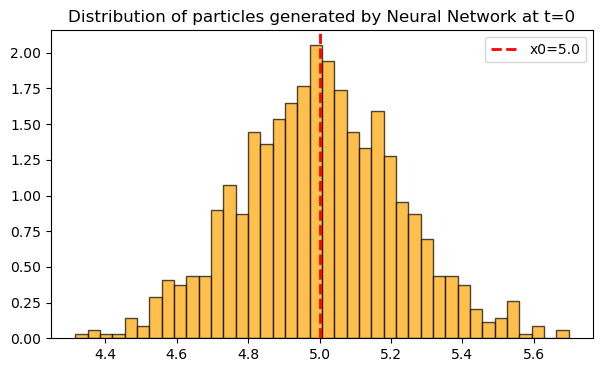

In [10]:
model.eval()

# Initialize from standard Gaussian Noise at t = T
x_rev_nn = torch.randn(n_particles, 1)
x_rev_nn_history = [x_rev_nn.detach().numpy().copy()]

t_rev_grid_tensor = torch.linspace(T, 0, N_steps + 1)

with torch.no_grad():
    for i in range(N_steps):
        t_val = t_rev_grid_tensor[i]
        # Avoid undefined error at t = 0
        if t_val == 0:
            break
            
        t_tensor = torch.full((n_particles, 1), t_val.item())
        noise = torch.randn(n_particles, 1)
        
        # Call Neural Network to compute score prediction
        score_nn = model(x_rev_nn, t_tensor)
        
        # Calculate Drift
        drift = -0.5 * beta * x_rev_nn - beta * score_nn
        
        # Update Reverse SDE (Time running backward, hence subtract dt)
        x_rev_nn = x_rev_nn - drift * dt + torch.sqrt(torch.tensor(beta * dt)) * noise
        x_rev_nn_history.append(x_rev_nn.detach().numpy().copy())

x_rev_nn_history = np.array(x_rev_nn_history).squeeze()

# Visualize the generated results from the neural network
plt.figure(figsize=(10, 5))
for i in range(30):
    # FIX: Remove [:-1] from t_rev_grid_tensor to match the length of x_rev_nn_history (1001)
    plt.plot(t_rev_grid_tensor.numpy(), x_rev_nn_history[:, i], alpha=0.3, color='orange', linewidth=0.5)

plt.title('Reverse SDE Generating Data from Noise (Using Trained Neural Network)')
plt.xlabel('Time t (backward from T to 0)')
plt.ylabel('Value x')
plt.xlim(T, 0) # Reverse axis to clearly see backward movement

plt.axhline(y=x0, color='red', linestyle='--', linewidth=2, label=f'Target Data (x = {x0})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Evaluate distribution of results at step t=0
plt.figure(figsize=(7, 4))
plt.hist(x_rev_nn_history[-1, :], bins=40, density=True, color='orange', alpha=0.7, edgecolor='black')
plt.axvline(x=x0, color='red', linestyle='dashed', linewidth=2, label=f'x0={x0}')
plt.title('Distribution of particles generated by Neural Network at t=0')
plt.legend()
plt.show()